In [14]:
import sys
import os

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../"))

import pandas as pd
import matplotlib.pyplot as plt

from data_loading import load_data
from eda import *


# Load Data

In [15]:
df = load_data()

Data loaded: (590540, 434)


# Preview 

In [16]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


# basic info 

In [17]:
basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


{'shape': (590540, 434),
 'num_columns': 434,
 'info': None,
 'dtypes': {dtype('float64'): 399, dtype('O'): 31, dtype('int64'): 4}}

# Target distribution

In [18]:
target_distribution(df)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

# Missing values

In [19]:
missing_values(df).head(20)

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
dtype: float64

# Missing visualization 

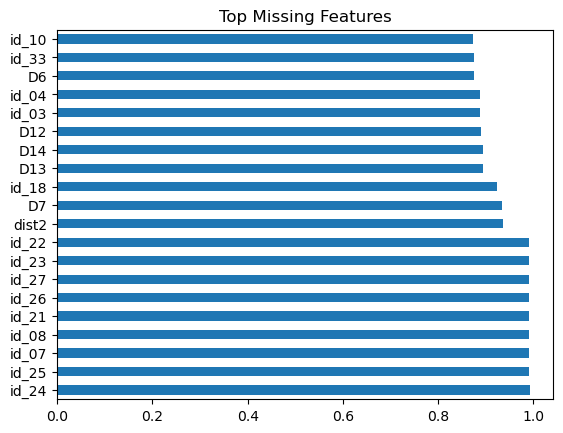

In [20]:
missing_values(df).head(20).plot(kind="barh")
plt.title("Top Missing Features")
plt.show()

# Fraud over time 

In [21]:
fraud_hour = fraud_by_hour(df)
fraud_hour

hour
0.000000     0.000000
0.000278     0.142857
0.000556     0.000000
0.000833     0.000000
0.001111     0.000000
               ...   
23.998611    0.000000
23.998889    0.000000
23.999167    0.000000
23.999444    0.000000
23.999722    0.000000
Name: isFraud, Length: 86400, dtype: float64

# Plot fraud over time

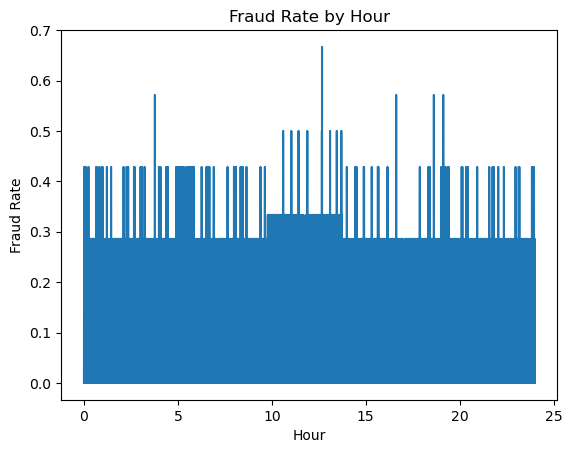

Saved plot at: /Users/wend-yamemilemariejeanrichardnikiema/Documents/fraud-detection-ieeee/outputs/fraud_by_hour.png


In [31]:
plt.figure()
fraud_hour.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")


# Save the image in folder output
filepath = os.path.join(OUTPUT_PATH, "fraud_by_hour.png")
plt.savefig(filepath, bbox_inches="tight") 
plt.show()
plt.close()
print(f"Saved plot at: {os.path.abspath(filepath)}")

# Save the report

In [32]:
results = {
        "basic_info": basic_info(df),
        "missing_top_20": missing_values(df).head(20),
        "target_distribution": target_distribution(df),
        "fraud_by_hour": fraud_by_hour(df),
        "transaction_amount_stats": transaction_amount_stats(df),
    }

save_report(results)
print("Report saved.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
Report saved.


# Observations 

Observations:

- Dataset is highly imbalanced (~3-5% fraud)
- Certain hours show higher fraud rates
- Many features have missing values (>80%)
- Transaction amount differs between fraud and non-fraud

Conclusion:
Temporal features will be critical for modeling.